<a href="https://colab.research.google.com/github/Rafiah-Syed/Collaborative-Filtering/blob/main/Agentic_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q torch torchvision tqdm pandas scikit-learn

In [5]:
import torch
import torch.nn as nn
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [6]:
url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"

df = pd.read_csv(url, header=None)
df.columns = ["label", "title", "text"]

df["text"] = df["title"] + " " + df["text"]

df = df[["text", "label"]]

df = df.sample(5000, random_state=42).reset_index(drop=True)

df.head()

,text,label
0,"BBC set for major shake-up, claims newspaper L...",3
1,Marsh averts cash crunch Embattled insurance b...,3
2,"Jeter, Yankees Look to Take Control (AP) AP - ...",2
3,Flying the Sun to Safety When the Genesis caps...,4
4,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,3


In [7]:
from collections import Counter

counter = Counter()

for t in df["text"]:
    counter.update(t.lower().split())

vocab = {w:i+2 for i,(w,_) in enumerate(counter.most_common(10000))}
vocab["<pad>"] = 0
vocab["<unk>"] = 1

def encode(text):
    return [vocab.get(w,1) for w in text.lower().split()[:50]]

In [8]:
X = [encode(t) for t in df["text"]]
y = df["label"].values - 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [9]:
def pad(seq, max_len=50):
    seq = seq[:max_len]
    return seq + [0]*(max_len-len(seq))

In [10]:
def get_batch(X, y, batch_size=32):
    for i in range(0, len(X), batch_size):
        xb = torch.tensor([pad(x) for x in X[i:i+batch_size]]).to(device)
        yb = torch.tensor(y[i:i+batch_size]).to(device)
        yield xb, yb

In [11]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb=128, hid=256):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb)
        self.lstm = nn.LSTM(emb, hid, batch_first=True)

    def forward(self, x):
        x = self.emb(x)
        out, (h, c) = self.lstm(x)
        return out, h.squeeze(0)

In [12]:
class Bahdanau(nn.Module):
    def __init__(self, hid=256):
        super().__init__()
        self.W1 = nn.Linear(hid, hid)
        self.W2 = nn.Linear(hid, hid)
        self.V = nn.Linear(hid, 1)

    def forward(self, enc_out, hidden):

        hidden = hidden.unsqueeze(1)

        score = self.V(torch.tanh(
            self.W1(enc_out) + self.W2(hidden)
        ))

        attn = torch.softmax(score, dim=1)

        context = torch.sum(attn * enc_out, dim=1)

        return context

In [13]:
class Luong(nn.Module):
    def __init__(self, hid=256):
        super().__init__()
        self.W = nn.Linear(hid, hid)

    def forward(self, enc_out, hidden):

        hidden = hidden.unsqueeze(2)

        score = torch.bmm(self.W(enc_out), hidden).squeeze(2)

        attn = torch.softmax(score, dim=1)

        context = torch.bmm(attn.unsqueeze(1), enc_out).squeeze(1)

        return context

In [25]:
class Classifier(nn.Module):
    def __init__(self, hid=256):
        super().__init__()

        self.rnn = nn.LSTM(256, hid, batch_first=True)
        self.fc = nn.Linear(hid, 4)   # ✅ MUST BE 256 → 4 flow via hidden

    def forward(self, enc_out, context):

        if context.dim() == 3:
            context = context.squeeze(1)

        x = context.unsqueeze(1)   # (B,1,256)

        _, (h, _) = self.rnn(x)

        out = self.fc(h.squeeze(0))

        return out

In [15]:
class Model(nn.Module):
    def __init__(self, vocab_size, attn):
        super().__init__()
        self.encoder = Encoder(vocab_size)
        self.attn = attn
        self.classifier = Classifier()

    def forward(self, x):

        enc_out, hidden = self.encoder(x)

        context = self.attn(enc_out, hidden)

        return self.classifier(enc_out, context)

In [26]:
vocab_size = len(vocab)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bah_model = Model(vocab_size, Bahdanau()).to(device)
lu_model = Model(vocab_size, Luong()).to(device)

In [36]:
def train(model, epochs=3):

    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    model.train() # Set model to training mode

    for epoch in range(epochs):

        total = 0

        for xb, yb in get_batch(X_train, y_train):

            opt.zero_grad()

            out = model(xb)

            loss = loss_fn(out, yb)

            loss.backward()
            opt.step()

            total += loss.item()

        print("Epoch:", epoch+1, "Loss:", total)

In [37]:
print("Training Bahdanau...")
train(bah_model, 20)

print("Training Luong...")
train(lu_model, 20)

Training Bahdanau...
Epoch: 1 Loss: 155.43714153766632
Epoch: 2 Loss: 100.14953345060349
Epoch: 3 Loss: 64.66394241154194
Epoch: 4 Loss: 39.05731488764286
Epoch: 5 Loss: 22.25254830159247
Epoch: 6 Loss: 14.025788810104132
Epoch: 7 Loss: 9.150020429864526
Epoch: 8 Loss: 7.155191865283996
Epoch: 9 Loss: 2.181374850566499
Epoch: 10 Loss: 2.9776370730251074
Epoch: 11 Loss: 1.5315739291836508
Epoch: 12 Loss: 0.7245968282513786
Epoch: 13 Loss: 0.09845453249727143
Epoch: 14 Loss: 0.03192890805439674
Epoch: 15 Loss: 0.021971679154376034
Epoch: 16 Loss: 0.01649601979079307
Epoch: 17 Loss: 0.01300005187113129
Epoch: 18 Loss: 0.010574426372841117
Epoch: 19 Loss: 0.008796640297077829
Epoch: 20 Loss: 0.007442352691214182
Training Luong...
Epoch: 1 Loss: 152.85039973258972
Epoch: 2 Loss: 106.27510461211205
Epoch: 3 Loss: 67.56543773412704
Epoch: 4 Loss: 41.91610500961542
Epoch: 5 Loss: 24.923761701211333
Epoch: 6 Loss: 18.41516494937241
Epoch: 7 Loss: 11.548024486750364
Epoch: 8 Loss: 10.77149030007

In [38]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [39]:
def predict(model, X):
    model.eval()
    preds = []

    with torch.no_grad():
        for x in X:
            x = torch.tensor(pad(x)).unsqueeze(0).to(device)

            out = model(x)

            pred = torch.argmax(out, dim=1).cpu().numpy()[0]
            preds.append(pred)

    return np.array(preds)

In [40]:
print("Predicting Bahdanau...")
bah_preds = predict(bah_model, X_test)

print("Predicting Luong...")
lu_preds = predict(lu_model, X_test)

Predicting Bahdanau...
Predicting Luong...


In [49]:
print(" BAHADANAU RESULTS")
print("Accuracy:", accuracy_score(y_test, bah_preds))
print("F1 Score:", f1_score(y_test, bah_preds, average='weighted'))

print("\n LUONG RESULTS")
print("Accuracy:", accuracy_score(y_test, lu_preds))
print("F1 Score:", f1_score(y_test, lu_preds, average='weighted'))

 BAHADANAU RESULTS
Accuracy: 0.787
F1 Score: 0.7866258392246605

 LUONG RESULTS
Accuracy: 0.777
F1 Score: 0.7774007295501096


In [42]:
print("Bahdanau Confusion Matrix")
print(confusion_matrix(y_test, bah_preds))

print("\nLuong Confusion Matrix")
print(confusion_matrix(y_test, lu_preds))

Bahdanau Confusion Matrix
[[191  22  19  17]
 [ 15 235   9  14]
 [ 10   6 177  30]
 [ 18  20  33 184]]

Luong Confusion Matrix
[[193  22  25   9]
 [ 14 238  13   8]
 [ 26   2 163  32]
 [ 15  14  43 183]]


In [43]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Bahdanau", "Luong"],
    "Accuracy": [
        accuracy_score(y_test, bah_preds),
        accuracy_score(y_test, lu_preds)
    ],
    "F1 Score": [
        f1_score(y_test, bah_preds, average='weighted'),
        f1_score(y_test, lu_preds, average='weighted')
    ]
})

results

,Model,Accuracy,F1 Score
0,Bahdanau,0.787,0.786626
1,Luong,0.777,0.777401


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

classes = ["World", "Sports", "Business", "Sci/Tech"]

In [45]:
cm_bah = confusion_matrix(y_test, bah_preds)

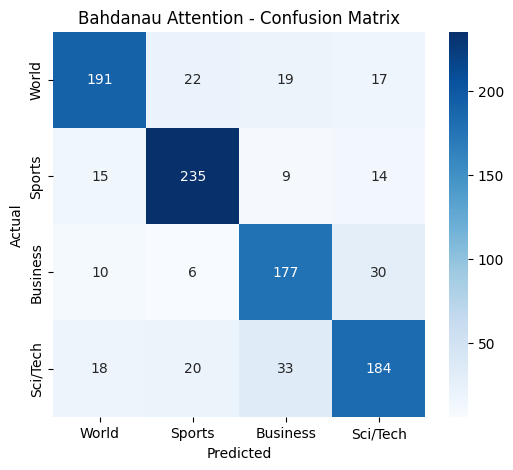

In [46]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_bah, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.title("Bahdanau Attention - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
cm_lu = confusion_matrix(y_test, lu_preds)

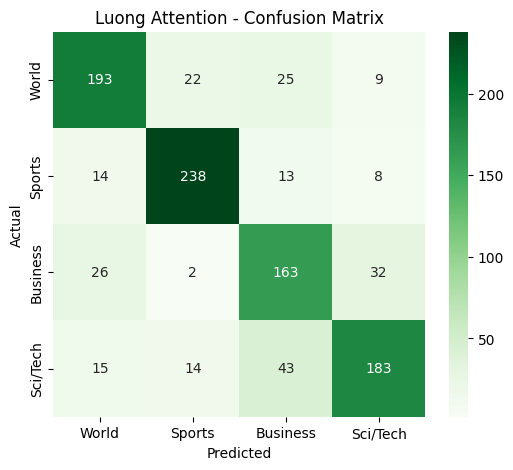

In [48]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_lu, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes,
            yticklabels=classes)

plt.title("Luong Attention - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
label_map = {
    0: "World news",
    1: "Sports news",
    2: "Business news",
    3: "Science technology news"
}

In [51]:
y_true_text = [label_map[y] for y in y_test]

In [52]:
bah_text = [label_map[p] for p in bah_preds]

In [53]:
lu_text = [label_map[p] for p in lu_preds]

In [54]:
!pip install -q evaluate rouge-score nltk

In [55]:
import evaluate

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

In [56]:
print(" BAHADANAU ROUGE")
print(rouge.compute(predictions=bah_text, references=y_true_text))

print("\n LUONG ROUGE")
print(rouge.compute(predictions=lu_text, references=y_true_text))

 BAHADANAU ROUGE
{'rouge1': np.float64(0.8808999999999978), 'rouge2': np.float64(0.787), 'rougeL': np.float64(0.8799999999999981), 'rougeLsum': np.float64(0.8802999999999981)}

 LUONG ROUGE
{'rouge1': np.float64(0.8767999999999984), 'rouge2': np.float64(0.777), 'rougeL': np.float64(0.8763999999999983), 'rougeLsum': np.float64(0.876199999999998)}


In [57]:
print(" BAHADANAU BLEU")
print(bleu.compute(predictions=bah_text, references=y_true_text))

print("\nLUONG BLEU")
print(bleu.compute(predictions=lu_text, references=y_true_text))

 BAHADANAU BLEU
{'bleu': 0.0, 'precisions': [0.8779510022271715, 0.7799196787148595, 0.7510204081632653, 0.0], 'brevity_penalty': 0.9955555628877929, 'length_ratio': 0.9955654101995566, 'translation_length': 2245, 'reference_length': 2255}

LUONG BLEU
{'bleu': 0.0, 'precisions': [0.8781362007168458, 0.7792207792207793, 0.7887931034482759, 0.0], 'brevity_penalty': 0.9897482516058821, 'length_ratio': 0.98980044345898, 'translation_length': 2232, 'reference_length': 2255}


In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"

df = pd.read_csv(url, header=None)
df.columns = ["label", "title", "text"]

# combine title + text
df["text"] = df["title"] + " " + df["text"]

# keep only needed columns
df = df[["text", "label"]]


df = df.sample(5000, random_state=42).reset_index(drop=True)

# -----------------------------
#  CREATE "SUMMARY" TARGET
# -----------------------------
label_map = {
    0: "World news summary",
    1: "Sports news summary",
    2: "Business news summary",
    3: "Science and technology news summary"
}

df["summary"] = df["label"].map(label_map)

# -----------------------------
#  TRAIN / TEST SPLIT
# -----------------------------
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df.head())

                                                text  label  \
0  Women in Business Face the  #39;Glass Cliff #3...      4   
1  Backward chute switch probed NASA #39;s Genesi...      4   
2  Energised Henman downs Dupuis Basel - Two-time...      2   
3  UPDATE 2-Coolbrands shares melt as guidance di...      3   
4  Chad, US-Malaysian Oil Group Disagree Chad wil...      3   

                               summary  
0                                  NaN  
1                                  NaN  
2                Business news summary  
3  Science and technology news summary  
4  Science and technology news summary  


In [64]:
from collections import Counter
import re

In [67]:
def tokenizer(text):
    if not isinstance(text, str):
        return []   # handle NaN safely

    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9 ]", "", text)
    return text.split()

In [68]:
counter = Counter()

for text in train_df["text"]:
    counter.update(tokenizer(text))

for text in train_df["summary"]:
    counter.update(tokenizer(text))

In [69]:
max_vocab = 20000

vocab = {
    word: idx + 4
    for idx, (word, _) in enumerate(counter.most_common(max_vocab))
}

In [70]:
vocab["<pad>"] = 0
vocab["<unk>"] = 1
vocab["<sos>"] = 2
vocab["<eos>"] = 3

In [71]:
def encode_summary(text):
    return [2] + [vocab.get(w, 1) for w in tokenizer(text)] + [3]

In [72]:
print(encode(train_df["text"].iloc[0])[:20])
print(encode_summary(train_df["summary"].iloc[0])[:20])

[555, 9, 14, 310, 4, 1, 6535, 1, 555, 43, 2042, 2769, 1101, 4, 3133, 3134, 5, 212, 3135, 12]
[2, 3]


In [73]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

In [74]:
MAX_LEN_SRC = 100   # article
MAX_LEN_TGT = 20    # summary

In [75]:
def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))  # 0 = <pad>
    else:
        seq = seq[:max_len]
    return seq

In [76]:
class NewsDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        src = encode(self.df.loc[idx, "text"])
        tgt = encode_summary(self.df.loc[idx, "summary"])

        src = pad_sequence(src, MAX_LEN_SRC)
        tgt = pad_sequence(tgt, MAX_LEN_TGT)

        return torch.tensor(src), torch.tensor(tgt)

In [77]:
train_dataset = NewsDataset(train_df)
test_dataset = NewsDataset(test_df)

In [78]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [79]:
src, tgt = next(iter(train_loader))

print("Source shape:", src.shape)   # (B, MAX_LEN_SRC)
print("Target shape:", tgt.shape)   # (B, MAX_LEN_TGT)

Source shape: torch.Size([32, 100])
Target shape: torch.Size([32, 20])


In [81]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [82]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB_SIZE = len(vocab)
EMB_DIM = 128
HID_DIM = 256

In [132]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(VOCAB_SIZE, EMB_DIM)
        self.lstm = nn.LSTM(EMB_DIM, HID_DIM, batch_first=True, bidirectional=True)

    def forward(self, x):
        # x: (B, T)
        emb = self.embedding(x)        # (B, T, EMB)
        outputs, (h, c) = self.lstm(emb)

        return outputs, h

In [133]:
class BahdanauAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.W1 = nn.Linear(HID_DIM * 2, HID_DIM)
        self.W2 = nn.Linear(HID_DIM, HID_DIM)
        self.V = nn.Linear(HID_DIM, 1)

    def forward(self, enc_out, hidden):
        # enc_out: (B, T, 2H)
        # hidden: (B, H)

        hidden = hidden.unsqueeze(1)  # (B,1,H)

        score = torch.tanh(self.W1(enc_out) + self.W2(hidden))
        attention = self.V(score).squeeze(-1)  # (B,T)

        weights = F.softmax(attention, dim=1)
        context = torch.sum(weights.unsqueeze(-1) * enc_out, dim=1)

        return context, weights

In [139]:
class LuongAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.W = nn.Linear(HID_DIM * 2, HID_DIM)

    def forward(self, enc_out, hidden):
        # enc_out: (B,T,2H)
        # hidden: (B,H)

        hidden = hidden.unsqueeze(2)  # (B,H,1)

        enc_proj = self.W(enc_out)    # (B,T,H)

        score = torch.bmm(enc_proj, hidden).squeeze(-1)  # (B,T)

        weights = F.softmax(score, dim=1)
        context = torch.sum(weights.unsqueeze(-1) * enc_out, dim=1)

        return context, weights

In [138]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(VOCAB_SIZE, EMB_DIM)

        self.lstm = nn.LSTM(EMB_DIM + HID_DIM * 2, HID_DIM, batch_first=True)

        self.fc = nn.Linear(HID_DIM, VOCAB_SIZE)

    def forward(self, x, context, hidden):

        # x: (B,)
        x = self.embedding(x).unsqueeze(1)   # (B,1,E)

        context = context.unsqueeze(1)       # (B,1,2H)

        x = torch.cat([x, context], dim=2)   # (B,1,E+2H)

        out, hidden = self.lstm(x)

        out = self.fc(out.squeeze(1))

        return out, hidden

In [137]:
class Seq2Seq(nn.Module):
    def __init__(self, attention_type="bahdanau"):
        super().__init__()

        self.encoder = Encoder()

        if attention_type == "bahdanau":
            self.attention = BahdanauAttention()
        else:
            self.attention = LuongAttention()

        self.decoder = Decoder()

        self.attention_type = attention_type

    def forward(self, src, tgt):

        enc_out, hidden = self.encoder(src)

        B, T = tgt.shape

        outputs = torch.zeros(B, T, VOCAB_SIZE).to(DEVICE)

        dec_input = tgt[:, 0]  # <sos>

        for t in range(1, T):

            # hidden state fix
            h = hidden[0][-1] if isinstance(hidden, tuple) else hidden[-1]

            context, _ = self.attention(enc_out, h)

            output, hidden = self.decoder(dec_input, context, hidden)

            outputs[:, t] = output

            dec_input = tgt[:, t]

        return outputs

In [140]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss(ignore_index=0)
def train_model(model, loader, epochs=6, lr=0.001):

    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

        for src, tgt in loop:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)

            optimizer.zero_grad()

            output = model(src, tgt)  # (B,T,V)

            # reshape for loss
            output = output[:, 1:].reshape(-1, VOCAB_SIZE)
            tgt = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            loop.set_postfix(loss=loss.item())

        print(f"\nEpoch {epoch+1} Loss: {total_loss/len(loader):.4f}")

In [141]:
bah_model = Seq2Seq(attention_type="bahdanau").to(DEVICE)
lu_model = Seq2Seq(attention_type="luong").to(DEVICE)

In [143]:
print(" Training Bahdanau Attention Model...")
train_model(bah_model, train_loader, epochs=15)

print("\n Training Luong Attention Model...")
train_model(lu_model, train_loader, epochs=15)

 Training Bahdanau Attention Model...


Epoch 1/15: 100%|██████████| 125/125 [00:17<00:00,  7.03it/s, loss=0.383]



Epoch 1 Loss: 0.3809


Epoch 2/15: 100%|██████████| 125/125 [00:15<00:00,  8.07it/s, loss=0.375]



Epoch 2 Loss: 0.3775


...


Epoch 13 Loss: 0.3784


Epoch 14/15: 100%|██████████| 125/125 [00:13<00:00,  9.22it/s, loss=0.355]



Epoch 14 Loss: 0.3772


Epoch 15/15: 100%|██████████| 125/125 [00:13<00:00,  9.21it/s, loss=0.43]


Epoch 15 Loss: 0.3780


In [91]:
!pip install -q evaluate rouge-score nltk

import evaluate
import torch
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

In [144]:
def generate_summary(model, src):

    model.eval()

    src = torch.tensor(src).unsqueeze(0).to(DEVICE)

    enc_out, hidden = model.encoder(src)

    dec_input = torch.tensor([2]).to(DEVICE)  # <sos>

    output_sentence = []

    for _ in range(MAX_LEN_TGT):

        h = hidden[0][-1] if isinstance(hidden, tuple) else hidden[-1]

        context, _ = model.attention(enc_out, h)

        output, hidden = model.decoder(dec_input, context, hidden)

        pred_token = torch.argmax(output, dim=1).item()

        if pred_token == 3:  # <eos>
            break

        output_sentence.append(pred_token)

        dec_input = torch.tensor([pred_token]).to(DEVICE)

    return output_sentence

In [145]:
inv_vocab = {v:k for k,v in vocab.items()}

def decode(tokens):
    return " ".join([inv_vocab.get(t, "<unk>") for t in tokens])

In [146]:
bah_preds_text = []
lu_preds_text = []
refs_text = []

for i in range(200):

    src_text = encode(test_df["text"].iloc[i])
    ref_text = test_df["summary"].iloc[i]

    # Bahdanau
    bah_out = generate_summary(bah_model, src_text)
    bah_preds_text.append(decode(bah_out))

    # Luong
    lu_out = generate_summary(lu_model, src_text)
    lu_preds_text.append(decode(lu_out))

    refs_text.append(ref_text)

In [147]:
print(" BAHADANAU ROUGE")
print(rouge.compute(predictions=bah_preds_text, references=refs_text))

print("\n LUONG ROUGE")
print(rouge.compute(predictions=lu_preds_text, references=refs_text))

 BAHADANAU ROUGE
{'rouge1': np.float64(0.4720471014492752), 'rouge2': np.float64(0.4300595238095237), 'rougeL': np.float64(0.4721920289855071), 'rougeLsum': np.float64(0.4698188405797099)}

 LUONG ROUGE
{'rouge1': np.float64(0.4825), 'rouge2': np.float64(0.3999999999999998), 'rougeL': np.float64(0.4825), 'rougeLsum': np.float64(0.48)}
